# 08 - State revisions and innovations

Exploits the state-space structure to compare the **real-time (filtered)** and
**retrospective (smoothed)** estimates of the time-varying coefficients, and to
inspect the model's one-step-ahead **innovations**, relative to market stress.

- The **filtered** state $m_t$ uses information up to $t$ (real-time view).
- The **smoothed** state $\theta_t\mid y_{1:T}$ uses the full sample (hindsight).
- The **revision** $\theta_t^{\text{smooth}}-\theta_t^{\text{filter}}$ measures how
  much the real-time estimate is later revised. It is zero at the sample end.
- The **innovation** $e_t=Y_t-F_t a_t$ is the one-step-ahead forecast error.

Estimated on the constant-variance DLM (notebook 04), where filtered and smoothed
states are exact. Risk is proxied by the VIX level and the Bai-Perron break dates.

> **Note.** The revision is an *estimate* revision (the smoother uses future data),
> not directly a measure of market expectations.

## Setup

In [1]:
import ast
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

CURRENCIES = ["CHF", "EUR", "GBP", "JPY"]
RATE = {"CHF": "CHF_3M", "EUR": "EUR_3M", "GBP": "GBP_3M", "JPY": "JPY_3M"}
REGRESSORS = ["SP500", "UST10Y", "fxvol", "TED", "VIX"]
TERMS = ["const"] + REGRESSORS
LAMBDA = 1e-3
DATA_DIR = Path("..") / "data"
FIG_DIR = Path("..") / "figures"; FIG_DIR.mkdir(exist_ok=True)

## Load, construct, and fit the DLM

For each currency, fit the constant-variance DLM and collect the filtered and
smoothed coefficient paths and the innovations.

In [2]:
levels = pd.read_csv(DATA_DIR / "levels.csv", index_col="date", parse_dates=True)
fx = levels[CURRENCIES].dropna()
appreciation = np.log(fx).diff()
sp500_d = np.log(levels["SP500"]).diff().rename("SP500")
vix_d = np.log(levels["VIX"]).diff().rename("VIX")
ust10y_d = levels["UST10Y"].diff().rename("UST10Y")
ted_d = ((levels["US_3M"] - levels["TBILL_3M"]) / 360).rename("TED")
# interbank rates are % p.a.; /100/360 gives the daily decimal carry
interest_diff = pd.DataFrame({cur: (levels[RATE[cur]] - levels["US_3M"]) / 100 / 360 for cur in CURRENCIES})
excess = appreciation + interest_diff
realized = np.log(appreciation.rolling(30).std())
fx_vol = pd.DataFrame({cur: realized[[o for o in CURRENCIES if o != cur]].mean(axis=1) for cur in CURRENCIES})
fx_vol = fx_vol - fx_vol.mean()   # centre log-vol so it does not offset the intercept

def model_frame(cur):
    return pd.concat([excess[cur].rename("excess"), sp500_d, ust10y_d,
                      fx_vol[cur].rename("fxvol"), ted_d, vix_d], axis=1).dropna()

class DLM(sm.tsa.statespace.MLEModel):
    def __init__(self, Y, F, W, m0, C0):
        p = F.shape[1]; super().__init__(endog=Y, k_states=p, k_posdef=p)
        self["design"] = F.T.reshape(1, p, len(Y)); self["transition"] = np.eye(p)
        self["selection"] = np.eye(p); self["state_cov"] = W; self.initialize_known(m0, C0)
    @property
    def param_names(self): return ["V"]
    @property
    def start_params(self): return [np.var(self.endog)]
    def transform_params(self, u): return u ** 2
    def untransform_params(self, p): return np.sqrt(np.abs(p))
    def update(self, params, **kw):
        params = super().update(params, **kw); self["obs_cov", 0, 0] = params[0]

def fit_dlm(cur):
    df = model_frame(cur)
    Y = df["excess"].values
    F = np.column_stack([np.ones(len(df))] + [df[r].values for r in REGRESSORS])
    ols = sm.OLS(Y, F).fit()
    C0 = ols.mse_resid * np.linalg.inv(F.T @ F)
    # BFGS may warn 'failed to converge': the likelihood in V is flat at
    # machine precision near the optimum; the estimate and the smoothed
    # states are unchanged under maxiter=500, so the warning is spurious.
    res = DLM(Y, F, LAMBDA * np.diag(np.diag(C0)), ols.params, C0).fit(disp=False)
    filt = pd.DataFrame(res.filtered_state.T, index=df.index, columns=TERMS)
    smoo = pd.DataFrame(res.smoothed_state.T, index=df.index, columns=TERMS)
    innov = pd.Series(np.abs(res.forecasts_error[0]), index=df.index, name="innov")
    vixlvl = levels["VIX"].reindex(df.index).rename("vix")
    return {"df": df, "filtered": filt, "smoothed": smoo, "innov": innov, "vix": vixlvl}

dlm = {cur: fit_dlm(cur) for cur in CURRENCIES}

bp = {}
bp_path = DATA_DIR / "break_dates.csv"
if bp_path.exists():
    raw = pd.read_csv(bp_path, index_col=0)["break_dates"]
    bp = {cur: [pd.Timestamp(d) for d in ast.literal_eval(raw[cur])] for cur in raw.index}

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Real-time vs. hindsight: the fx-volatility coefficient

Filtered (real-time) versus smoothed (full-sample) path of the fx-volatility
coefficient. Gaps between the two show where hindsight revised the real-time
estimate; break dates (dotted) mark the regime shifts.

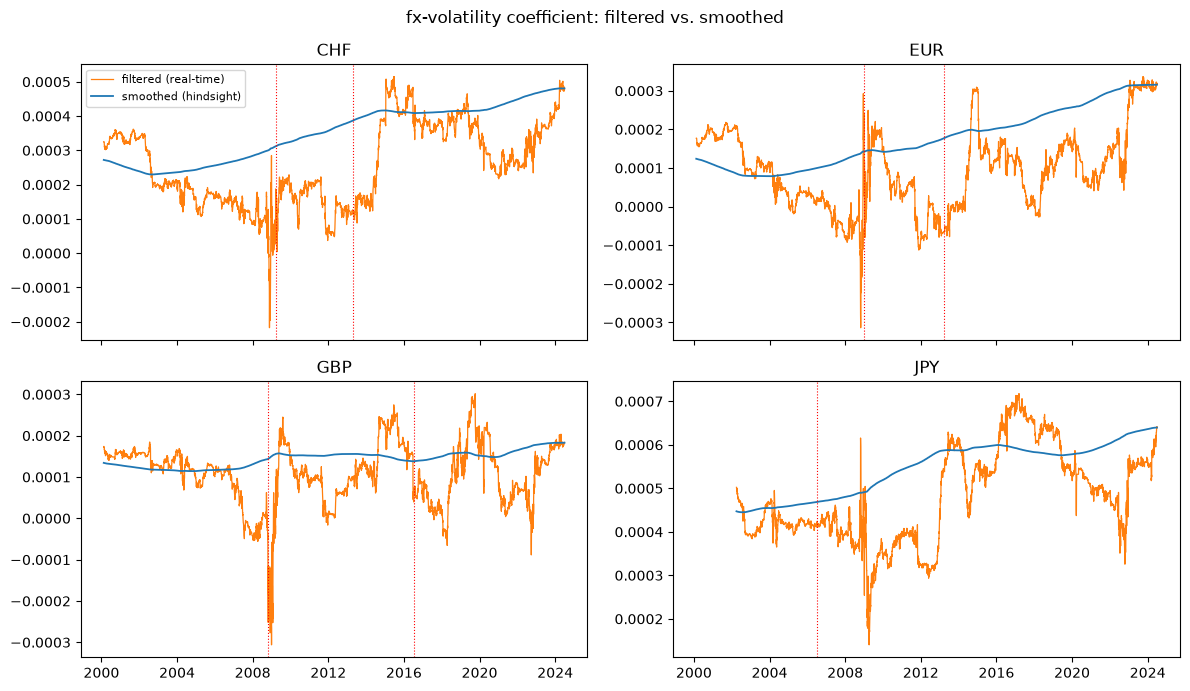

In [3]:
COEF = "fxvol"
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, cur in zip(axes.ravel(), CURRENCIES):
    d = dlm[cur]
    ax.plot(d["df"].index, d["filtered"][COEF], color="C1", lw=0.9, label="filtered (real-time)")
    ax.plot(d["df"].index, d["smoothed"][COEF], color="C0", lw=1.3, label="smoothed (hindsight)")
    for x in bp.get(cur, []):
        ax.axvline(x, color="red", ls=":", lw=0.8)
    ax.set_title(cur)
axes.ravel()[0].legend(fontsize=8)
fig.suptitle(r"fx-volatility coefficient: filtered vs. smoothed")
fig.tight_layout()
fig.savefig(FIG_DIR / "state_filtered_vs_smoothed.png", dpi=300, bbox_inches="tight")
plt.show()

## Revision magnitude and market stress

Absolute revision $|\theta_t^{\text{smooth}}-\theta_t^{\text{filter}}|$ of the
fx-volatility coefficient (left axis) against the VIX level (right axis), with
break dates.

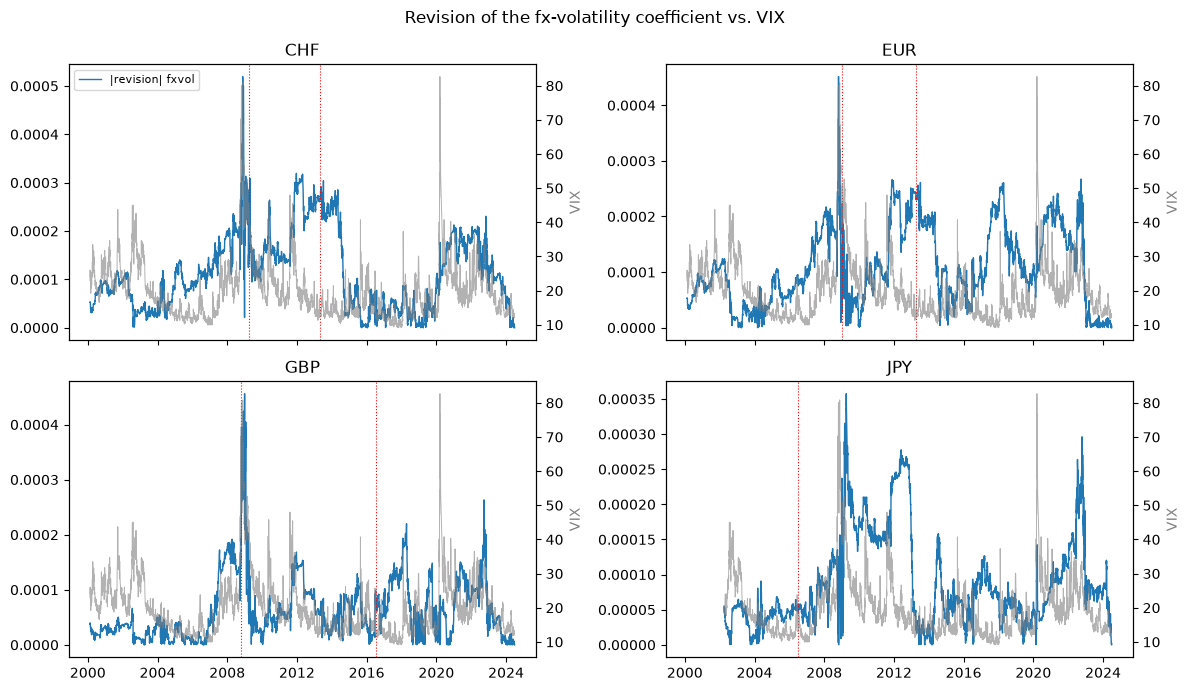

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, cur in zip(axes.ravel(), CURRENCIES):
    d = dlm[cur]
    rev = (d["smoothed"][COEF] - d["filtered"][COEF]).abs()
    ax.plot(rev.index, rev, color="C0", lw=1.0, label="|revision| fxvol")
    ax2 = ax.twinx()
    ax2.plot(d["vix"].index, d["vix"], color="grey", lw=0.7, alpha=0.6, label="VIX")
    ax2.set_ylabel("VIX", color="grey")
    for x in bp.get(cur, []):
        ax.axvline(x, color="red", ls=":", lw=0.8)
    ax.set_title(cur)
axes.ravel()[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Revision of the fx-volatility coefficient vs. VIX")
fig.tight_layout()
fig.savefig(FIG_DIR / "state_revision_vs_vix.png", dpi=300, bbox_inches="tight")
plt.show()

## Innovations and market stress

Absolute one-step-ahead innovation $|e_t|$ (left) against the VIX level (right).

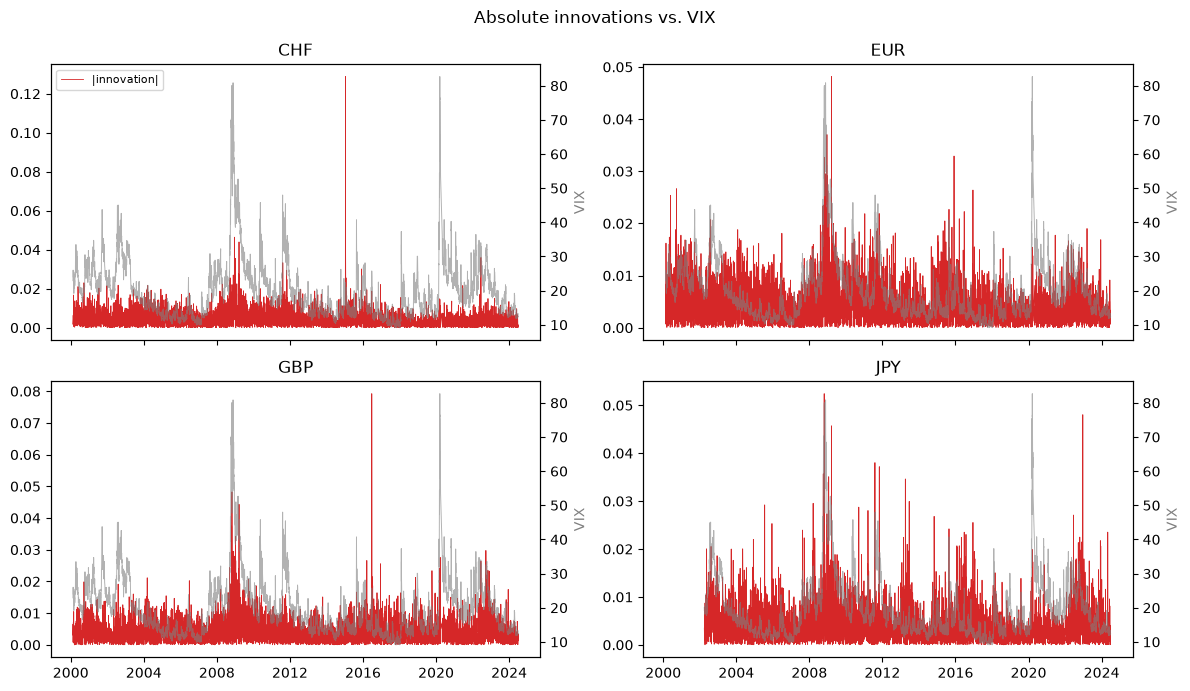

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, cur in zip(axes.ravel(), CURRENCIES):
    d = dlm[cur]
    ax.plot(d["innov"].index, d["innov"], color="C3", lw=0.6, label="|innovation|")
    ax2 = ax.twinx()
    ax2.plot(d["vix"].index, d["vix"], color="grey", lw=0.7, alpha=0.6)
    ax2.set_ylabel("VIX", color="grey")
    ax.set_title(cur)
axes.ravel()[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Absolute innovations vs. VIX")
fig.tight_layout()
fig.savefig(FIG_DIR / "state_innovations_vs_vix.png", dpi=300, bbox_inches="tight")
plt.show()

## Event window around structural breaks

Mean absolute fx-volatility revision within $\pm 60$ trading days of a break
date, relative to the baseline (away from breaks). A ratio above 1 means
revisions cluster around regime shifts.

In [6]:
WINDOW = 60
event_rows = []
for cur in CURRENCIES:
    d = dlm[cur]; idx = d["df"].index
    rev = (d["smoothed"][COEF] - d["filtered"][COEF]).abs()
    near = pd.Series(False, index=idx)
    for b in bp.get(cur, []):
        pos = idx.get_indexer([b], method="nearest")[0]
        near.iloc[max(0, pos - WINDOW):min(len(idx), pos + WINDOW + 1)] = True
    event_rows.append({"currency": cur,
                       "near_breaks": round(rev[near].mean(), 4),
                       "baseline": round(rev[~near].mean(), 4),
                       "ratio": round(rev[near].mean() / rev[~near].mean(), 2)})
event = pd.DataFrame(event_rows).set_index("currency")
event

,near_breaks,baseline,ratio
currency,,,
CHF,0.0002,0.0001,2.08
EUR,0.0002,0.0001,1.86
GBP,0.0001,0.0001,2.43
JPY,0.0001,0.0001,0.60


## Lead-lag with the VIX

Cross-correlation $\mathrm{corr}(|\text{revision}|_t,\ \mathrm{VIX}_{t+k})$ over
lags $k$. A peak at $k>0$ means the revision at $t$ lines up with VIX **after**
$t$, i.e. the revision reflects stress that arrives later.

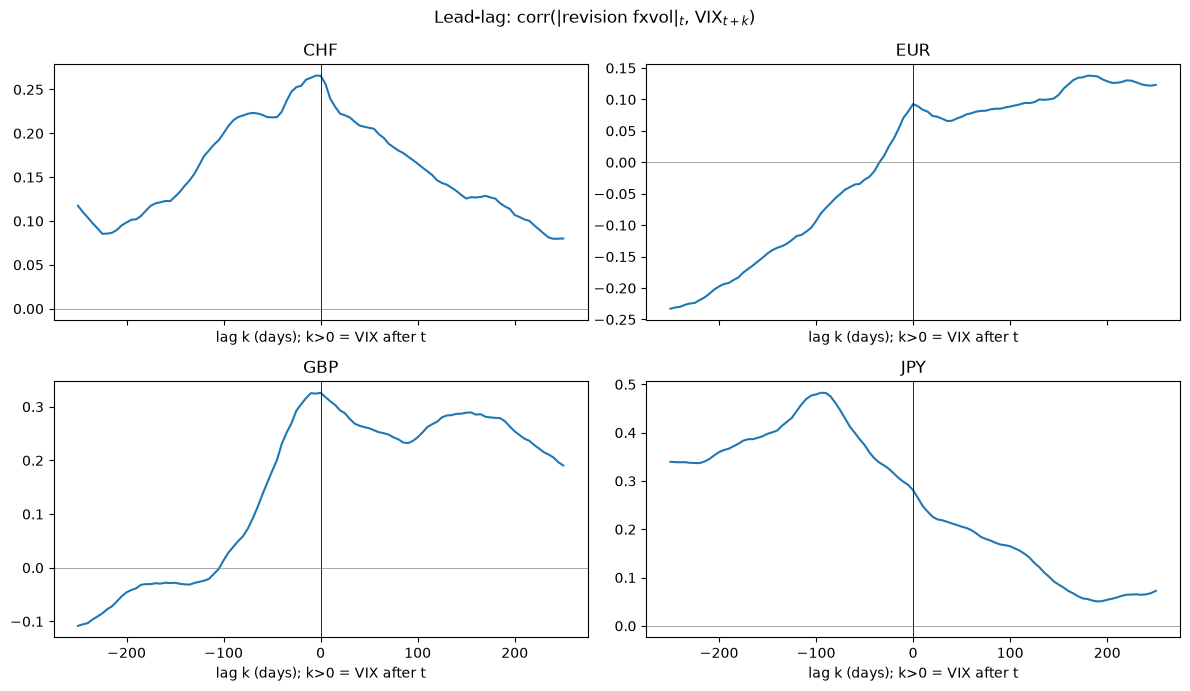

In [7]:
LAGS = list(range(-250, 251, 5))   # wide, so a real peak is not cut off at the edge
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, cur in zip(axes.ravel(), CURRENCIES):
    d = dlm[cur]
    rev = (d["smoothed"][COEF] - d["filtered"][COEF]).abs()
    cc = [rev.corr(d["vix"].shift(-k)) for k in LAGS]
    ax.plot(LAGS, cc, color="C0")
    ax.axvline(0, color="black", lw=0.6); ax.axhline(0, color="grey", lw=0.5)
    ax.set_title(cur); ax.set_xlabel("lag k (days); k>0 = VIX after t")
fig.suptitle(r"Lead-lag: corr(|revision fxvol|$_t$, VIX$_{t+k}$)")
fig.tight_layout()
fig.savefig(FIG_DIR / "state_leadlag.png", dpi=300, bbox_inches="tight")
plt.show()

## Summary and export

Combine the correlations, the event ratio and the lead-lag peak into one table,
saved to `../data/state_revisions.csv` and `../paper/state_revisions.tex`.

In [8]:
rows = []
for cur in CURRENCIES:
    d = dlm[cur]
    rev = (d["smoothed"][COEF] - d["filtered"][COEF]).abs()
    m = pd.concat([rev.rename("rev"), d["innov"], d["vix"]], axis=1).dropna()
    cc = {k: rev.corr(d["vix"].shift(-k)) for k in range(-250, 251, 5)}
    kpeak = max(cc, key=lambda k: abs(cc[k]))
    if abs(kpeak) == 250:
        print(f"{cur}: lead-lag peak at the grid edge -> censored, not interpretable")
    rows.append({"currency": cur,
                 "corr_rev_vix": round(m["rev"].corr(m["vix"]), 3),
                 "corr_inn_vix": round(m["innov"].corr(m["vix"]), 3),
                 "event_ratio": float(event.loc[cur, "ratio"]),
                 "leadlag_k": int(kpeak), "leadlag_corr": round(cc[kpeak], 3)})
summary = pd.DataFrame(rows).set_index("currency")
summary.to_csv(DATA_DIR / "state_revisions.csv")

L = [r"\begin{table}[H]", r"\centering",
     r"\caption{State-revision and innovation diagnostics. Correlations with the VIX level; "
     r"event ratio = mean $|$revision$|$ within $\pm60$ trading days of a break relative to baseline; "
     r"lead-lag $k$ = lag (days) maximising $|\mathrm{corr}(|\mathrm{rev}|_t,\mathrm{VIX}_{t+k})|$ "
     r"($k>0$: VIX after $t$).}",
     r"\label{tab:revisions}", r"\begin{tabular}{lrrrrr}", r"\toprule",
     r"Currency & corr(rev,VIX) & corr(inn,VIX) & event ratio & lead-lag $k$ & lead-lag corr \\",
     r"\midrule"]
for cur, r in summary.iterrows():
    L.append(f"{cur} & ${r['corr_rev_vix']:.3f}$ & ${r['corr_inn_vix']:.3f}$ & "
             f"${r['event_ratio']:.2f}$ & ${int(r['leadlag_k'])}$ & ${r['leadlag_corr']:.3f}$ " + r"\\")
L += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
(Path("..") / "paper").mkdir(exist_ok=True)
(Path("..") / "paper" / "state_revisions.tex").write_text("\n".join(L))
print("Wrote ../paper/state_revisions.tex")
summary

EUR: lead-lag peak at the grid edge -> censored, not interpretable
Wrote ../paper/state_revisions.tex


,corr_rev_vix,corr_inn_vix,event_ratio,leadlag_k,leadlag_corr
currency,,,,,
CHF,0.266,0.192,2.08,-5,0.266
EUR,0.093,0.244,1.86,-250,-0.233
GBP,0.326,0.266,2.43,0,0.326
JPY,0.281,0.187,0.60,-95,0.483
